In [ ]:
!pip install git+https://github.com/Starlitnightly/dynamo-release.git

In [2]:
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
print(f'dynamo version: {dyn.__version__}')

dynamo version: 1.4.2rc1


In [3]:
#adata=dyn.read('data/setty_bone_marrow.h5ad')
adata=dyn.sample_data.bone_marrow()
adata

|-----> Downloading data to ./data/bone_marrow.h5ad
|-----> File ./data/bone_marrow.h5ad already exists.


AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

In [4]:
adata.layers['counts']=adata.X.copy()

In [5]:
adata=adata[~adata.obs['clusters'].isin(['CLP'])]
adata

View of AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced', 'counts'

In [6]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(adata, recipe='monocle')

|-----> Running monocle preprocessing pipeline...


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/preprocessing/Preprocessor.py:251: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["pp"] = {}


|-----------> filtered out 0 outlier cells
|-----------> filtered out 20923 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [52.6976s]
|-----> [Cell Cycle Scores Estimation] completed [0.8044s]
|-----> [Preprocessor-monocle] completed [33.0077s]


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/preprocessing/cell_cycle.py:462: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_cycle_scores["cell_cycle_order"] = cell_cycle_scores.groupby("cell_cycle_phase").cumcount()
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/preprocessing/cell_cycle.py:463: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_cycle_scores["cell_cycle_order"] = cell_cycle_scores.groupby("cell_cycle_phase", group_keys=False)[


In [7]:
dyn.tl.reduceDimension(adata)
adata

|-----> retrieve data for non-linear dimension reduction...
|-----> [UMAP] using X_pca with n_pca_components = 30
|-----> <insert> X_umap to obsm in AnnData Object.
|-----> [UMAP] completed [31.4954s]


AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_cv', 'log_m', 'frac', 'use_for_pca', 'ntr'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'neighbors', 'umap_fit'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'cell_cycle_scores', 'X_umap'
    layers: 'spliced', 'unspliced', 'counts', 'X_spliced', 'X_unspliced', 'X_counts'

In [8]:
del adata.uns['neighbors']
dyn.tl.reduceDimension(adata)

|-----> retrieve data for non-linear dimension reduction...
|-----? adata already have basis umap. dimension reduction umap will be skipped! 
set enforce=True to re-performing dimension reduction.
|-----> Start computing neighbor graph...
|-----------> X_data is None, fetching or recomputing...
|-----> fetching X data from layer:None, basis:pca
|-----> method arg is None, choosing methods automatically...
|-----------> method pynn selected
|-----> [UMAP] completed [9.6407s]


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


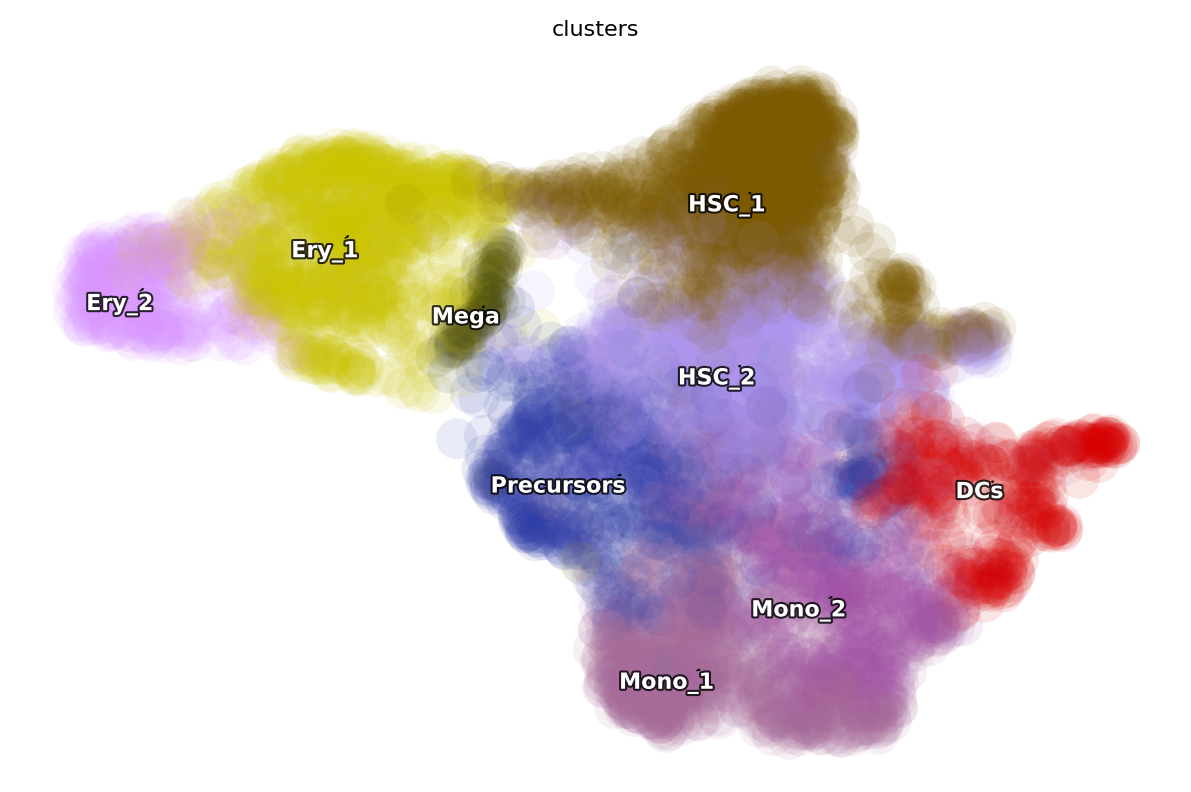

In [9]:
#dyn.tl.reduceDimension(adata)
dyn.pl.umap(adata, color='clusters',
           save_show_or_return='show',
            adjust_legend=True)

In [10]:
adata

AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_cv', 'log_m', 'frac', 'use_for_pca', 'ntr'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'umap_fit', 'neighbors'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'cell_cycle_scores', 'X_umap'
    layers: 'spliced', 'unspliced', 'counts', 'X_spliced', 'X_unspliced', 'X_counts'
    obsp: 'distances', 'connectivities'

In [11]:
adata.layers['M_s']=adata.X
dyn.tl.pseudotime_velocity(adata,
                          pseudotime='palantir_pseudotime')

|-----> Embrace RNA velocity and velocity vector field analysis for pseudotime...
|-----> Retrieve neighbor graph and pseudotime...
|-----> Computing transition graph via calculating pseudotime gradient with hodge method...
|-----> Use pseudotime transition matrix to learn low dimensional velocity projection.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.9729s]
|-----> Use pseudotime transition matrix to learn gene-wise velocity vectors.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [30.6899s]


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


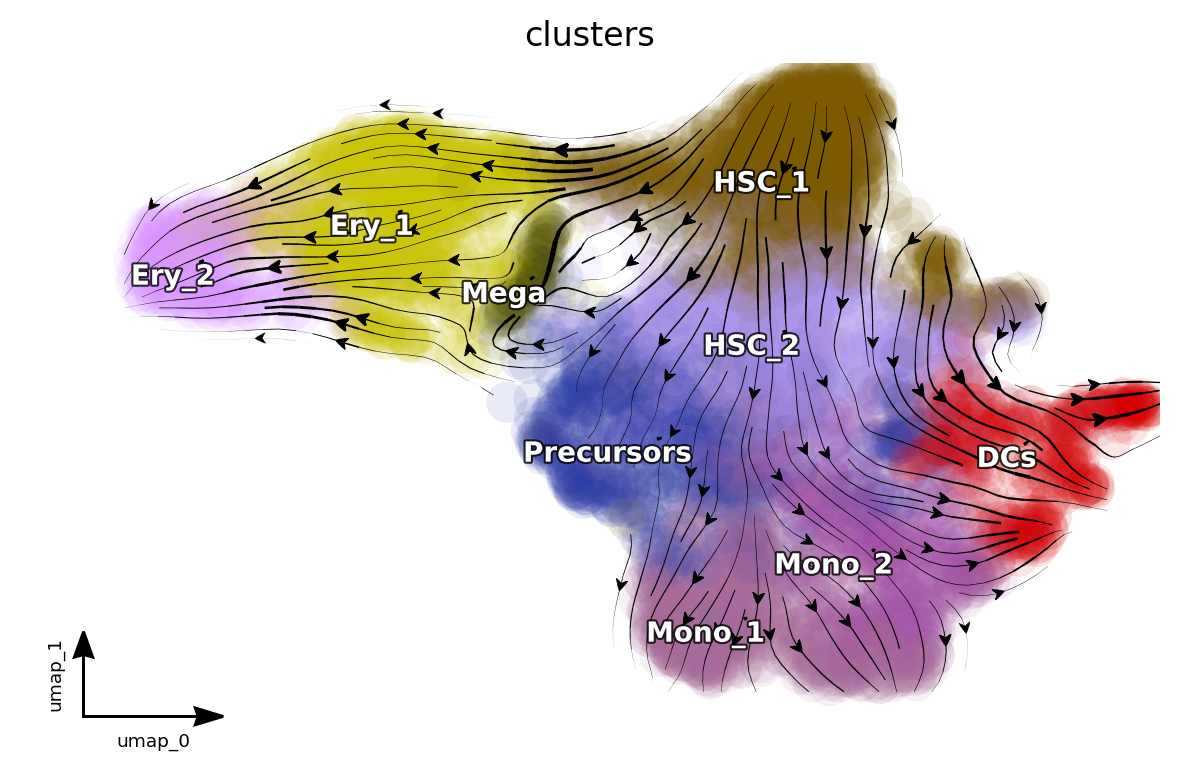

In [12]:
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

In [13]:
color_dict={'HSC_1': '#fcd4e4',
 'HSC_2': '#f494a4',
 'Ery_1': '#cc141c',
 'Mono_1': '#043464',
 'Precursors': '#acd4ec',
 'Mono_2': '#3474ac',
 'DCs': '#143c3c',
 'Ery_2': '#8c1c24',
 'Mega': '#fcc43c'}

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'HSC:CellType\n[PseudoTime]')

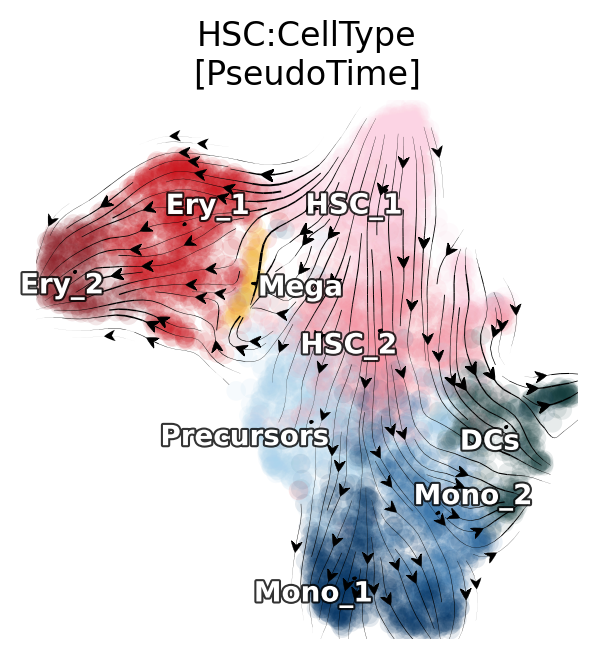

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       color_key=color_dict,
                       title='HSC:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('HSC:CellType\n[PseudoTime]',fontsize=12)
#fig.savefig(f'figures/fig3/Pt_HSC_Velo.png', dpi=300, bbox_inches='tight')

In [15]:
# you can set `verbose = 1/2/3` to obtain different levels of running information of vector field reconstruction

dyn.vf.VectorField(adata, basis='umap', M=100, pot_curl_div=True) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [7.9735s]
|-----> Running ddhodge to estimate vector field based pseudotime in umap basis...
|-----> graphizing vectorfield...
|-----------> calculating neighbor indices...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> not all cells are used, set diag to 1...
|-----------> Constructing W matrix according upsampling=True and downsampling=True options...
|-----> [ddhodge completed] completed [30.4003s]
|-----> Computing curl..

/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/external/hodge.py:227: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.06701024  1.2022482  -2.85233725 ...  1.61598196 -7.85506459
  2.65940491]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[adata.obs_names[cell_idx], prefix + "ddhodge_div"] = ddhodge_div
Calculating 2-D curl: 100%|██████████| 5292/5292 [00:00<00:00, 23111.33it/s]

|-----> Computing divergence...



Calculating divergence: 100%|██████████| 6/6 [00:00<00:00, 31.91it/s]


|-----> [VectorField] completed [39.1238s]


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin' will be ignored
  ax.scatter(
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x7f1cb2ac9480>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Text(0.5, 1.0, 'HSC:Topography\n[PseudoTime]')

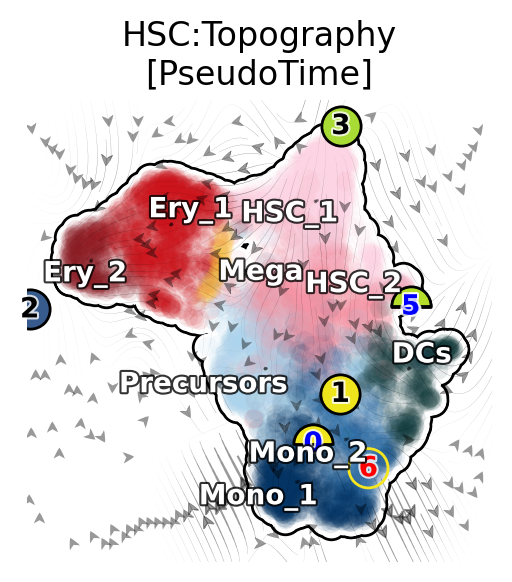

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'clusters'], 
                  color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('HSC:Topography\n[PseudoTime]',fontsize=12)
#fig.savefig(f'figures/fig3/Pt_HSC_Topography.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin' will be ignored
  ax.scatter(
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x7f1cb2536800>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Text(0.5, 1.0, 'HSC:Potential\n[PseudoTime]')

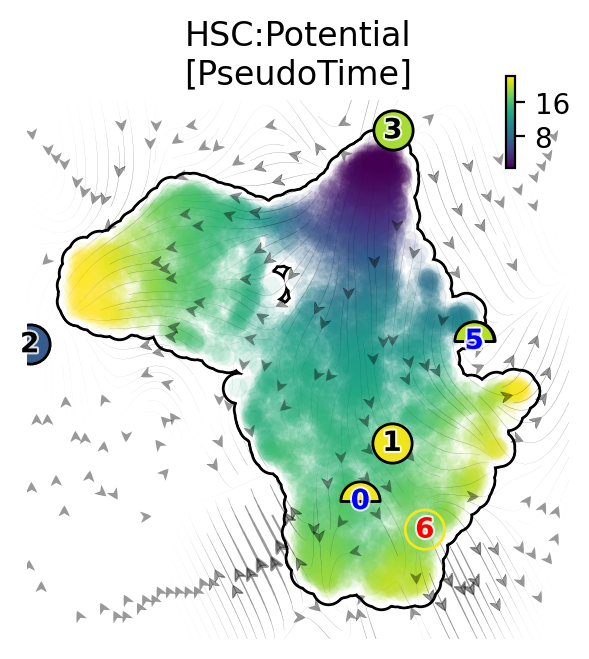

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('HSC:Potential\n[PseudoTime]',fontsize=12)
#fig.savefig(f'figures/fig3/Pt_HSC_Potential.png', dpi=300, bbox_inches='tight')
#fig